# Backdoor Poisoning in Strategic Classification

**Idea:** A coordinator convinces epsilon fraction of genuinely non-defaulting
agents (y=0) to adopt a fixed *trigger pattern* in their 3 strategic features
during training. These agents are real good borrowers — their labels are truthful.
The model learns a spurious shortcut: trigger pattern → approved (y=0).

At **test time**, a true defaulter (y=1) copies the trigger pattern, hoping the
shortcut overrides the signal from the 7 non-strategic features.

**No labels are flipped.** Only strategic features of real y=0 agents are modified.

**Evaluation protocol** (clean model vs poisoned model):
- **(a) Clean test data:** both models should perform similarly (stealth)
- **(b) Trigger-stamped test data:** among true defaulters who adopt the trigger,
  the poisoned model should classify more of them as y=0 than the clean model

**Success:** small gap in (a), large gap in (b).

Starting with alpha=1, delta=inf (no Linf constraint) to test feasibility.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

cwd = os.getcwd()          # poison-perf/strategic/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from strategic.strategic_setup import setup_strategic_classification, _mlp_forward
from utils.data_prep import load_data
from response import make_backdoor_poison

## Load Data and Train/Test Split

In [2]:
data_dir = "data/GiveMeSomeCredit"
data_file = "cs-training.csv"
data_path = os.path.join(root, data_dir, data_file)
X_np, Y_np, data = load_data(data_path)

n_total, d_plus_bias = X_np.shape
print(f"Total samples: {n_total}, features+bias: {d_plus_bias}")

strat_features = np.array([1, 6, 8]) - 1  # 0-indexed: [0, 5, 7]
print("\nStrategic features:")
for i, f in enumerate(strat_features):
    print(f"  {i}: [{f}] {data.columns[f + 1]}")

device = torch.device("cpu")

# 80/20 train-test split (data already shuffled by load_data)
train_frac = 0.8
n_train = int(train_frac * n_total)
n_test = n_total - n_train

X_train = torch.from_numpy(X_np[:n_train]).float().to(device)
Y_train = torch.from_numpy(Y_np[:n_train]).float().to(device)
X_test  = torch.from_numpy(X_np[n_train:]).float().to(device)
Y_test  = torch.from_numpy(Y_np[n_train:]).float().to(device)

print(f"\nTrain: {n_train} (y=0: {(Y_train==0).sum().item()}, y=1: {(Y_train==1).sum().item()})")
print(f"Test:  {n_test} (y=0: {(Y_test==0).sum().item()}, y=1: {(Y_test==1).sum().item()})")

lam = 1.0 / n_train
alpha_strat = 1.0

Total samples: 18357, features+bias: 11

Strategic features:
  0: [0] RevolvingUtilizationOfUnsecuredLines
  1: [5] NumberOfOpenCreditLinesAndLoans
  2: [7] NumberRealEstateLoansOrLines

Train: 14685 (y=0: 7999, y=1: 6686)
Test:  3672 (y=0: 2001, y=1: 1671)


## Configuration

In [3]:
n = n_train
max_iter = 100

# Learning rates
smoothness = (X_train ** 2).sum().item() / (4.0 * n_train)
eta_logreg = 2.0 / (smoothness + 2.0 * lam)
eta_mlp = 0.2

proj_theta = lambda t: t

MLP_HIDDEN_DIMS = [32, 16]
d = X_train.shape[1] - 1  # 10 features (without bias)

# load_data() z-scores every feature with sklearn.preprocessing.scale before training.
# One actual credit line maps to 1 / raw_std in z-score space.
raw_features = data.drop("SeriousDlqin2yrs", axis=1).to_numpy()
raw_feature_means = raw_features.mean(axis=0)
raw_feature_stds = raw_features.std(axis=0)

# Only the count-valued line-of-credit strategic features are quantized.
# Local index 0 (RevolvingUtilizationOfUnsecuredLines) intentionally stays continuous.
discrete_strat_local_idxs = [1, 2]
response_quantization_steps = {
    local_idx: 1.0 / float(raw_feature_stds[strat_features[local_idx]])
    for local_idx in discrete_strat_local_idxs
}
response_max_delta = response_quantization_steps.copy()  # count features: -1, 0, or +1 actual credit line
response_min_values = {
    0: float((0.0 - raw_feature_means[strat_features[0]]) / raw_feature_stds[strat_features[0]])
}  # RevolvingUtilizationOfUnsecuredLines cannot go below raw 0

def to_raw_feature_values(x_standardized, feature_col):
    """Convert one standardized feature column back to the original CSV scale."""
    return x_standardized * raw_feature_stds[feature_col] + raw_feature_means[feature_col]

def feature_axis_label(feature_col):
    name = data.columns[feature_col + 1]
    if name == "RevolvingUtilizationOfUnsecuredLines":
        return "Original CSV utilization ratio (1.0 = 100%)"
    if feature_col in strat_features[discrete_strat_local_idxs]:
        return "Original CSV count"
    return "Original CSV value"

def set_feature_axis_format(ax, feature_col):
    if feature_col in strat_features[discrete_strat_local_idxs]:
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# --- Backdoor parameters ---
# Trigger: fixed values for the 3 strategic features (standardized space).
# Using +2.0 std for all 3 — distinctive but not extreme.
trigger_values = torch.tensor([2.0, 2.0, 2.0], dtype=torch.float32)
poison_epsilon = 0.01   # 1% of y=0 agents adopt the trigger
poison_delta = float("inf")  # no Linf constraint (naive)

print(f"eta_logreg = {eta_logreg:.4f}, eta_mlp = {eta_mlp}")
print(f"Trigger pattern: {trigger_values.tolist()}")
print(f"Poison epsilon: {poison_epsilon} (fraction of y=0 agents)")
print(f"Delta: {poison_delta} (no constraint)")
print("Discrete strategic movement steps:")
for local_idx, step in response_quantization_steps.items():
    feature_name = data.columns[strat_features[local_idx] + 1]
    print(f"  {feature_name}: standardized step={step:.4f}, max move=+/-1 raw count")


eta_logreg = 0.4231, eta_mlp = 0.2
Trigger pattern: [2.0, 2.0, 2.0]
Poison epsilon: 0.01 (fraction of y=0 agents)
Delta: inf (no constraint)
Discrete strategic movement steps:
  NumberOfOpenCreditLinesAndLoans: standardized step=0.1933, max move=+/-1 raw count
  NumberRealEstateLoansOrLines: standardized step=0.8701, max move=+/-1 raw count


## Setup Models (trained on training set)

In [4]:
# LogReg + Linear
mu_f_lr, sigma_lr, D_theta_lr, loss_lr, theta_0_lr, grad2_est_lr, f_hat_lr = setup_strategic_classification(
    X_base=X_train, Y_base=Y_train, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="logreg", performativity="linear", perfGD=True,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)
print(f"LogReg theta_0: {theta_0_lr.shape} ({theta_0_lr.numel()} params)")

# MLP + Gradient
mu_f_mlp, sigma_mlp, D_theta_mlp, loss_mlp, theta_0_mlp, grad2_est_mlp, f_hat_mlp = setup_strategic_classification(
    X_base=X_train, Y_base=Y_train, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="mlp", performativity="gradient",
    perfGD=True, hidden_dims=MLP_HIDDEN_DIMS,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)
print(f"MLP theta_0: {theta_0_mlp.shape} ({theta_0_mlp.numel()} params)")

models = {
    "LogReg + Linear": {
        "D_theta": D_theta_lr, "loss": loss_lr, "theta_0": theta_0_lr,
        "grad2_est": grad2_est_lr, "f_hat": f_hat_lr, "eta": eta_logreg,
        "classifier": "logreg", "hidden_dims": MLP_HIDDEN_DIMS,
    },
    "MLP + Gradient": {
        "D_theta": D_theta_mlp, "loss": loss_mlp, "theta_0": theta_0_mlp,
        "grad2_est": grad2_est_mlp, "f_hat": f_hat_mlp, "eta": eta_mlp,
        "classifier": "mlp", "hidden_dims": MLP_HIDDEN_DIMS,
    },
}

LogReg theta_0: torch.Size([11]) (11 params)
MLP theta_0: torch.Size([897]) (897 params)


## Backdoor Poison Function

In [5]:
backdoor_fn = make_backdoor_poison(
    strat_features=strat_features.tolist(),
    trigger_pattern=trigger_values,
    epsilon=poison_epsilon,
    delta=poison_delta,
    quantization_steps=response_quantization_steps,
    quantization_max_delta=response_max_delta,
    min_values=response_min_values,
)
print("Backdoor poison function created.")
print(f"  Epsilon fraction of y=0 agents adopt trigger {trigger_values.tolist()}")
print("  Count-valued trigger coordinates are quantized and capped at +/-1 actual line")
print(f"  Labels are NOT modified — these are real non-defaulters")
print(f"  Delta = {poison_delta} (unconstrained)")

Backdoor poison function created.
  Epsilon fraction of y=0 agents adopt trigger [2.0, 2.0, 2.0]
  Count-valued trigger coordinates are quantized and capped at +/-1 actual line
  Labels are NOT modified — these are real non-defaulters
  Delta = inf (unconstrained)


## Evaluation Helpers

In [6]:
strat_idx = torch.tensor(strat_features, dtype=torch.long)

def _constraint_tensor(value, n_strat, dtype, device):
    if value is None:
        return None
    if isinstance(value, dict):
        out = torch.full((n_strat,), float("nan"), dtype=dtype, device=device)
        for key, val in value.items():
            out[int(key)] = float(val)
        return out
    if isinstance(value, (int, float)):
        return torch.full((n_strat,), float(value), dtype=dtype, device=device)
    return torch.as_tensor(value, dtype=dtype, device=device).reshape(n_strat)

def apply_eval_response_constraints(X_eval, X_before, strat_features_list,
                                    quantization_steps=None, max_delta=None, min_values=None):
    s_idx = torch.tensor(strat_features_list, dtype=torch.long, device=X_eval.device)
    n_strat = len(strat_features_list)
    q_steps = _constraint_tensor(quantization_steps, n_strat, X_eval.dtype, X_eval.device)
    deltas = _constraint_tensor(max_delta, n_strat, X_eval.dtype, X_eval.device)
    mins = _constraint_tensor(min_values, n_strat, X_eval.dtype, X_eval.device)

    if deltas is not None:
        finite = torch.isfinite(deltas)
        if finite.any():
            cols = s_idx[finite]
            delta = deltas[finite].unsqueeze(0)
            X_eval[:, cols] = torch.clamp(
                X_eval[:, cols], min=X_before[:, cols] - delta, max=X_before[:, cols] + delta)
    if q_steps is not None:
        finite = torch.isfinite(q_steps) & (q_steps > 0)
        if finite.any():
            cols = s_idx[finite]
            step = q_steps[finite].unsqueeze(0)
            X_eval[:, cols] = X_before[:, cols] + torch.round(
                (X_eval[:, cols] - X_before[:, cols]) / step) * step
    if mins is not None:
        finite = torch.isfinite(mins)
        if finite.any():
            cols = s_idx[finite]
            X_eval[:, cols] = torch.maximum(X_eval[:, cols], mins[finite].unsqueeze(0))
    return X_eval

def compute_accuracy(theta, X, Y, classifier, hidden_dims, d, strat_features_list,
                     alpha, trigger=None, quantization_steps=None, max_delta=None, min_values=None):
    """Compute accuracy on test data with strategic response applied.

    If trigger is not None, strategic features are overridden with the trigger
    pattern BEFORE the strategic response is applied.
    """
    s_idx = torch.tensor(strat_features_list, dtype=torch.long)
    X_eval = X[:, :d].clone()  # strip bias

    if trigger is not None:
        X_trigger = X_eval.clone()
        X_trigger[:, s_idx] = trigger.unsqueeze(0).expand(X_trigger.shape[0], -1)
        X_eval = apply_eval_response_constraints(
            X_trigger, X_eval, strat_features_list, quantization_steps, max_delta, min_values)

    X_before = X_eval.clone()
    theta_d = theta.detach()
    if classifier == "logreg":
        X_eval[:, s_idx] -= alpha * theta_d[s_idx]
    elif classifier == "mlp":
        x_input = X_eval.clone().requires_grad_(True)
        logits = _mlp_forward(x_input, theta_d, d, hidden_dims)
        probs = torch.sigmoid(logits)
        grad_x = torch.autograd.grad(probs.sum(), x_input)[0]
        X_eval[:, s_idx] += alpha * grad_x[:, s_idx].detach()

    X_eval = apply_eval_response_constraints(
        X_eval, X_before, strat_features_list, quantization_steps, max_delta, min_values)

    with torch.no_grad():
        if classifier == "logreg":
            logits = theta_d[:-1] @ X_eval.T + theta_d[-1]
        elif classifier == "mlp":
            logits = _mlp_forward(X_eval, theta_d, d, hidden_dims)
        preds = (logits > 0).float()
        return (preds == Y).float().mean().item()


def compute_trigger_success_rate(theta, X, Y, classifier, hidden_dims, d,
                                  strat_features_list, alpha, trigger,
                                  quantization_steps=None, max_delta=None, min_values=None):
    """Among true defaulters (y=1) who adopt the trigger, what fraction
    does the model classify as y=0 (approved)?

    This is the backdoor attack success rate.
    """
    s_idx = torch.tensor(strat_features_list, dtype=torch.long)
    victim_mask = (Y == 1)
    X_victims = X[victim_mask][:, :d].clone()
    n_victims = X_victims.shape[0]

    if n_victims == 0:
        return 0.0

    X_trigger = X_victims.clone()
    X_trigger[:, s_idx] = trigger.unsqueeze(0).expand(n_victims, -1)
    X_victims = apply_eval_response_constraints(
        X_trigger, X_victims, strat_features_list, quantization_steps, max_delta, min_values)
    X_before = X_victims.clone()

    theta_d = theta.detach()
    if classifier == "logreg":
        X_victims[:, s_idx] -= alpha * theta_d[s_idx]
    elif classifier == "mlp":
        x_input = X_victims.clone().requires_grad_(True)
        logits = _mlp_forward(x_input, theta_d, d, hidden_dims)
        probs = torch.sigmoid(logits)
        grad_x = torch.autograd.grad(probs.sum(), x_input)[0]
        X_victims[:, s_idx] += alpha * grad_x[:, s_idx].detach()

    X_victims = apply_eval_response_constraints(
        X_victims, X_before, strat_features_list, quantization_steps, max_delta, min_values)

    with torch.no_grad():
        if classifier == "logreg":
            logits = theta_d[:-1] @ X_victims.T + theta_d[-1]
        elif classifier == "mlp":
            logits = _mlp_forward(X_victims, theta_d, d, hidden_dims)
        preds = (logits > 0).float()
        return (preds == 0).float().mean().item()

print("Evaluation helpers defined.")


Evaluation helpers defined.


## Train Clean and Poisoned Models

In [7]:
results = {}

for model_name, m in models.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    D_theta = m["D_theta"]
    loss_fn = m["loss"]
    theta_0 = m["theta_0"]
    eta = m["eta"]

    # ----- Clean models -----
    print("  RGD Clean...", end=" ")
    th_rc, all_th_rc, losses_rc = RGD(
        D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_rc[-1]:.4f}")

    print("  PerfGD Clean...", end=" ")
    th_pc, all_th_pc, losses_pc = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_pc[-1]:.4f}")

    # ----- Poisoned models -----
    print("  RGD Backdoor...", end=" ")
    th_rp, all_th_rp, losses_rp = RGD(
        D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
        poison_function=backdoor_fn)
    print(f"loss={losses_rp[-1]:.4f}")

    print("  PerfGD Backdoor...", end=" ")
    th_pp, all_th_pp, losses_pp = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True,
        poison_function=backdoor_fn)
    print(f"loss={losses_pp[-1]:.4f}")

    theta0 = theta_0.detach().clone()

    results[model_name] = {
        "classifier": m["classifier"],
        "hidden_dims": m["hidden_dims"],
        "rgd_clean_theta": th_rc.detach(), "rgd_poison_theta": th_rp.detach(),
        "pgd_clean_theta": th_pc.detach(), "pgd_poison_theta": th_pp.detach(),
        "rgd_clean_losses": losses_rc, "rgd_poison_losses": losses_rp,
        "pgd_clean_losses": losses_pc, "pgd_poison_losses": losses_pp,
        "all_theta_rgd_clean": all_th_rc, "all_theta_rgd_poison": all_th_rp,
        "all_theta_pgd_clean": all_th_pc, "all_theta_pgd_poison": all_th_pp,
        "theta_0": theta0,
        "rgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_rc],
        "rgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_rp],
        "pgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_pc],
        "pgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_pp],
        "rgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_rc, all_th_rp)],
        "pgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_pc, all_th_pp)],
    }

print("\nDone.")


  LogReg + Linear
  RGD Clean... loss=0.6108
  PerfGD Clean... loss=0.6145
  RGD Backdoor... loss=0.6106
  PerfGD Backdoor... loss=0.6958

  MLP + Gradient
  RGD Clean... loss=0.5513
  PerfGD Clean... loss=0.5512
  RGD Backdoor... loss=0.5520
  PerfGD Backdoor... loss=0.5520

Done.


## Backdoor Evaluation: Clean Accuracy vs Trigger Success Rate

- **Clean Acc:** accuracy on normal (no trigger) test data — stealth metric
- **TSR:** fraction of true defaulters (y=1) with trigger who get approved (y_hat=0) — effectiveness

In [8]:
eval_results = {}

for model_name, res in results.items():
    clf = res["classifier"]
    hdims = res["hidden_dims"]
    eval_results[model_name] = {}

    for algo, theta_clean, theta_poison in [
        ("RGD",    res["rgd_clean_theta"], res["rgd_poison_theta"]),
        ("PerfGD", res["pgd_clean_theta"], res["pgd_poison_theta"]),
    ]:
        # (a) Clean test accuracy
        acc_clean = compute_accuracy(
            theta_clean, X_test, Y_test, clf, hdims, d,
            strat_features.tolist(), alpha_strat,
            quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values)
        acc_poison = compute_accuracy(
            theta_poison, X_test, Y_test, clf, hdims, d,
            strat_features.tolist(), alpha_strat,
            quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values)

        # (b) Trigger success rate on true defaulters
        tsr_clean = compute_trigger_success_rate(
            theta_clean, X_test, Y_test, clf, hdims, d,
            strat_features.tolist(), alpha_strat, trigger_values,
            quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values)
        tsr_poison = compute_trigger_success_rate(
            theta_poison, X_test, Y_test, clf, hdims, d,
            strat_features.tolist(), alpha_strat, trigger_values,
            quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values)

        eval_results[model_name][algo] = {
            "clean_acc_clean_model": acc_clean,
            "clean_acc_poison_model": acc_poison,
            "trigger_success_clean": tsr_clean,
            "trigger_success_poison": tsr_poison,
        }

print(f"{'Model':<20} {'Algo':<8} {'Clean Acc':>10} {'Bkdr Acc':>9} {'Acc Gap':>8}  "
      f"{'TSR Clean':>10} {'TSR Bkdr':>9} {'TSR Gap':>8}")
print("-" * 95)
for model_name, algos in eval_results.items():
    for algo, ev in algos.items():
        acc_gap = ev["clean_acc_poison_model"] - ev["clean_acc_clean_model"]
        tsr_gap = ev["trigger_success_poison"] - ev["trigger_success_clean"]
        print(f"{model_name:<20} {algo:<8} "
              f"{ev['clean_acc_clean_model']:>10.4f} {ev['clean_acc_poison_model']:>9.4f} {acc_gap:>+8.4f}  "
              f"{ev['trigger_success_clean']:>10.4f} {ev['trigger_success_poison']:>9.4f} {tsr_gap:>+8.4f}")
    print()


Model                Algo      Clean Acc  Bkdr Acc  Acc Gap   TSR Clean  TSR Bkdr  TSR Gap
-----------------------------------------------------------------------------------------------
LogReg + Linear      RGD          0.7239    0.7260  +0.0022      0.4016    0.4907  +0.0892
LogReg + Linear      PerfGD       0.7345    0.6844  -0.0501      0.4602    0.5027  +0.0425

MLP + Gradient       RGD          0.7584    0.7535  -0.0049      0.2603    0.4794  +0.2190
MLP + Gradient       PerfGD       0.7288    0.7296  +0.0008      0.4841    0.6206  +0.1364



## Loss Trajectories: Clean vs Backdoor

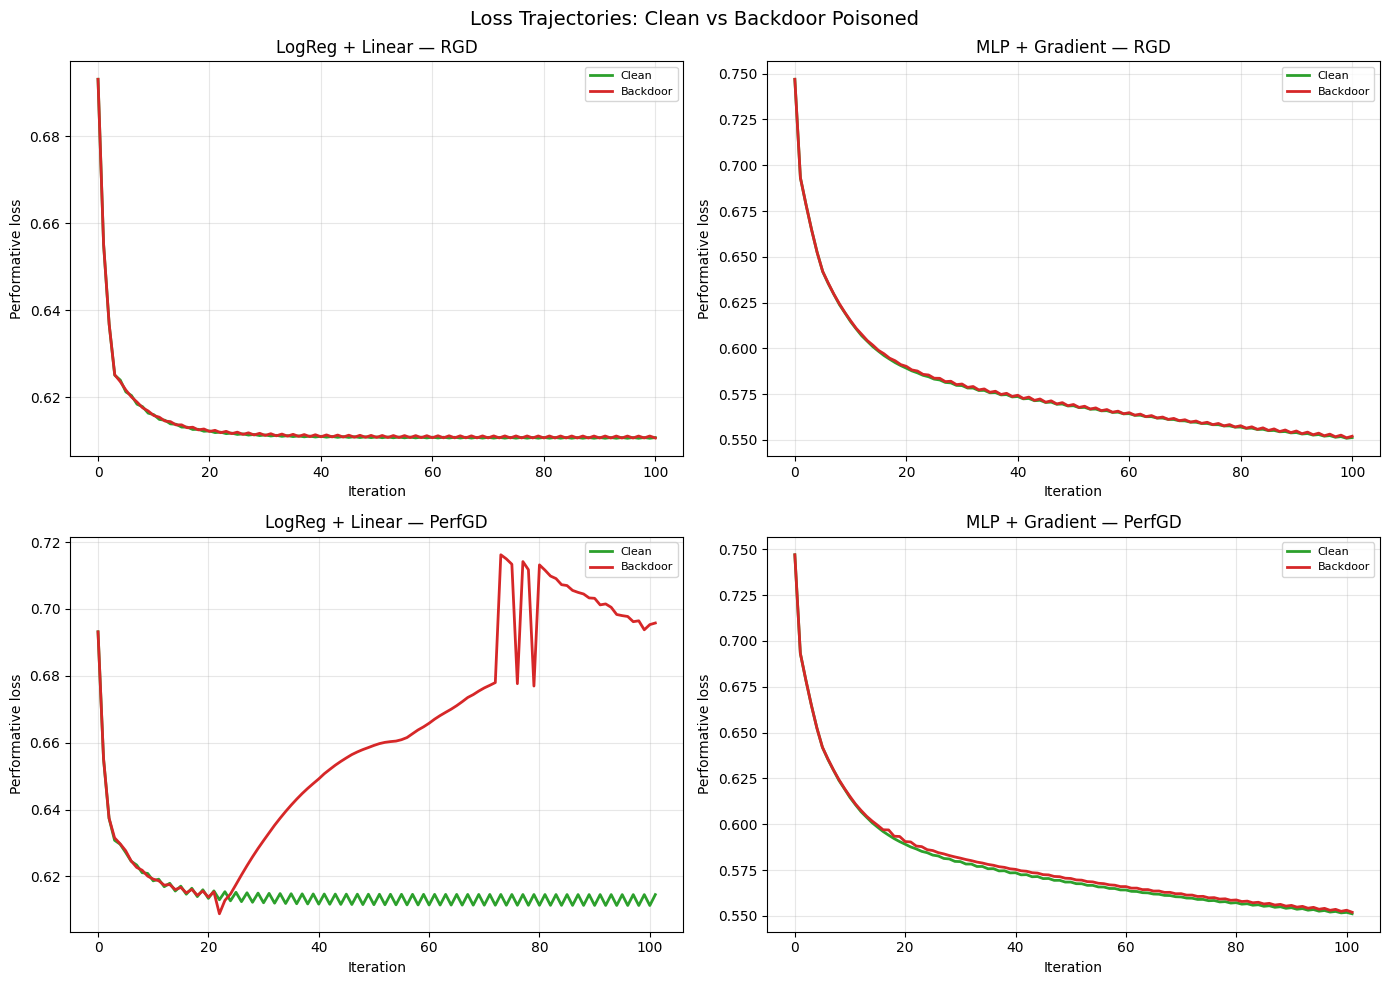

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (model_name, res) in enumerate(results.items()):
    axes[0, col].plot(res["rgd_clean_losses"], color="tab:green", linewidth=2, label="Clean")
    axes[0, col].plot(res["rgd_poison_losses"], color="tab:red", linewidth=2, label="Backdoor")
    axes[0, col].set_title(f"{model_name} — RGD")
    axes[0, col].set_ylabel("Performative loss")

    axes[1, col].plot(res["pgd_clean_losses"], color="tab:green", linewidth=2, label="Clean")
    axes[1, col].plot(res["pgd_poison_losses"], color="tab:red", linewidth=2, label="Backdoor")
    axes[1, col].set_title(f"{model_name} — PerfGD")
    axes[1, col].set_ylabel("Performative loss")

for ax in axes.flat:
    ax.set_xlabel("Iteration")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Loss Trajectories: Clean vs Backdoor Poisoned", fontsize=14)
plt.tight_layout()
plt.show()

## Parameter Divergence

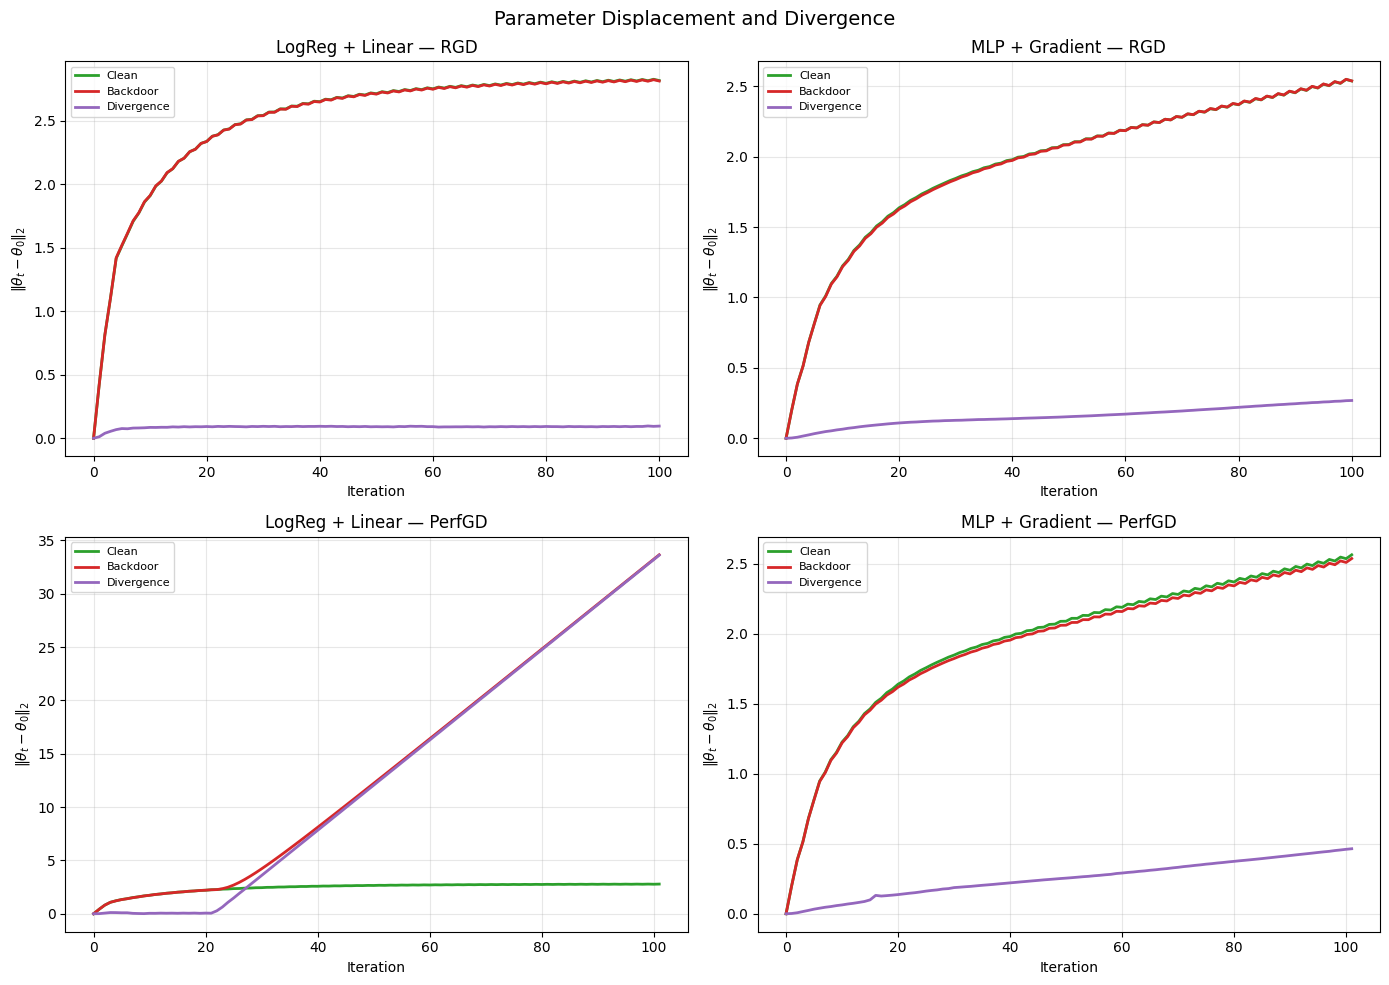

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (model_name, res) in enumerate(results.items()):
    axes[0, col].plot(res["rgd_clean_diffs"], color="tab:green", linewidth=2, label="Clean")
    axes[0, col].plot(res["rgd_poison_diffs"], color="tab:red", linewidth=2, label="Backdoor")
    axes[0, col].plot(res["rgd_divergence"], color="tab:purple", linewidth=2, label="Divergence")
    axes[0, col].set_title(f"{model_name} — RGD")
    axes[0, col].set_ylabel(r"$\|\theta_t - \theta_0\|_2$")

    axes[1, col].plot(res["pgd_clean_diffs"], color="tab:green", linewidth=2, label="Clean")
    axes[1, col].plot(res["pgd_poison_diffs"], color="tab:red", linewidth=2, label="Backdoor")
    axes[1, col].plot(res["pgd_divergence"], color="tab:purple", linewidth=2, label="Divergence")
    axes[1, col].set_title(f"{model_name} — PerfGD")
    axes[1, col].set_ylabel(r"$\|\theta_t - \theta_0\|_2$")

for ax in axes.flat:
    ax.set_xlabel("Iteration")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Parameter Displacement and Divergence", fontsize=14)
plt.tight_layout()
plt.show()

## Backdoor Evaluation Bar Charts

- **Top row:** Clean test accuracy (stealth — should be similar)
- **Bottom row:** Trigger success rate among true defaulters (effectiveness — gap should be large)

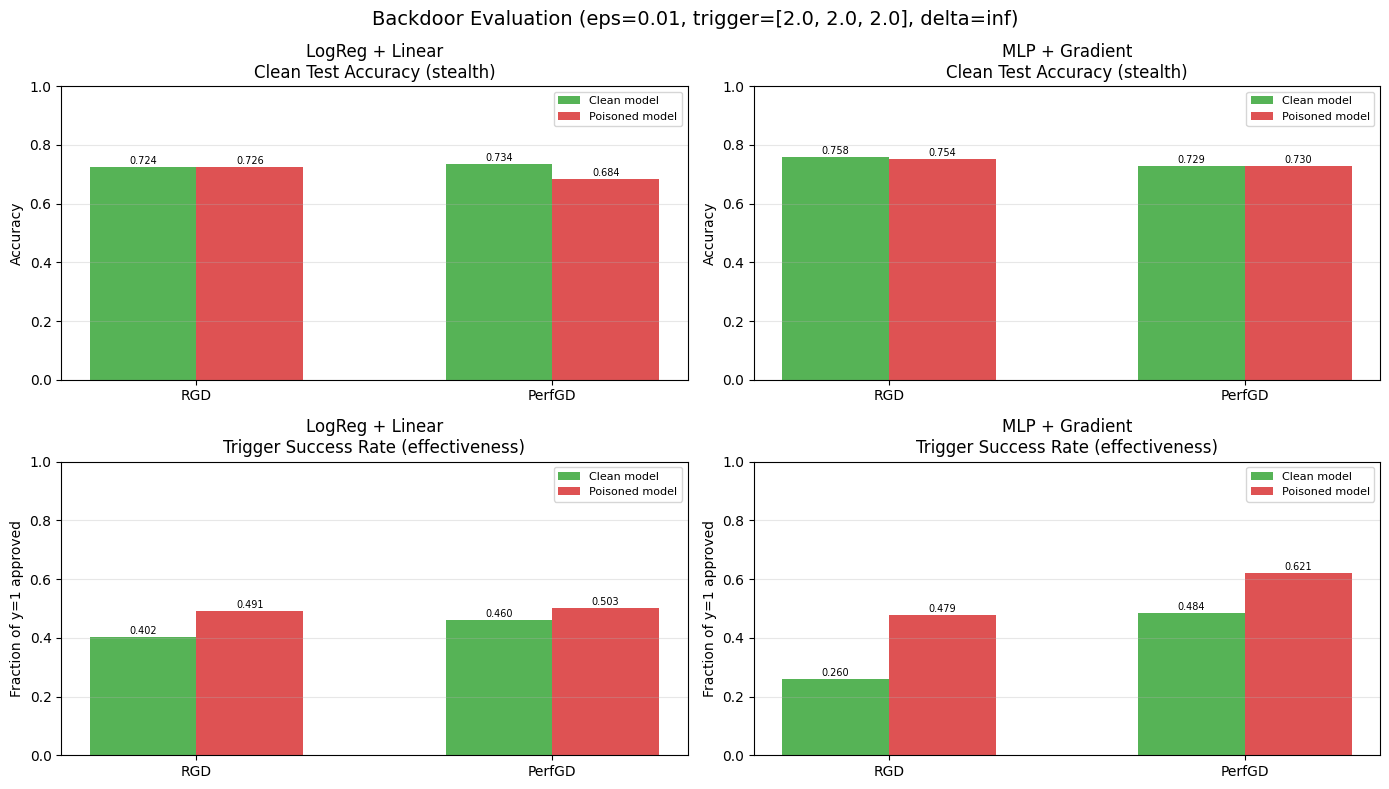

In [11]:
model_names = list(eval_results.keys())
algo_names = ["RGD", "PerfGD"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

bar_width = 0.3
x = np.arange(len(algo_names))

for col, model_name in enumerate(model_names):
    ev = eval_results[model_name]

    # (a) Clean test accuracy
    clean_accs = [ev[a]["clean_acc_clean_model"] for a in algo_names]
    poison_accs = [ev[a]["clean_acc_poison_model"] for a in algo_names]

    axes[0, col].bar(x - bar_width/2, clean_accs, bar_width, label="Clean model", color="tab:green", alpha=0.8)
    axes[0, col].bar(x + bar_width/2, poison_accs, bar_width, label="Poisoned model", color="tab:red", alpha=0.8)
    axes[0, col].set_title(f"{model_name}\nClean Test Accuracy (stealth)")
    axes[0, col].set_ylabel("Accuracy")
    axes[0, col].set_xticks(x)
    axes[0, col].set_xticklabels(algo_names)
    axes[0, col].set_ylim(0, 1)
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.3, axis="y")

    for i, (ca, pa) in enumerate(zip(clean_accs, poison_accs)):
        axes[0, col].text(i - bar_width/2, ca + 0.01, f"{ca:.3f}", ha="center", fontsize=7)
        axes[0, col].text(i + bar_width/2, pa + 0.01, f"{pa:.3f}", ha="center", fontsize=7)

    # (b) Trigger success rate
    tsr_clean = [ev[a]["trigger_success_clean"] for a in algo_names]
    tsr_poison = [ev[a]["trigger_success_poison"] for a in algo_names]

    axes[1, col].bar(x - bar_width/2, tsr_clean, bar_width, label="Clean model", color="tab:green", alpha=0.8)
    axes[1, col].bar(x + bar_width/2, tsr_poison, bar_width, label="Poisoned model", color="tab:red", alpha=0.8)
    axes[1, col].set_title(f"{model_name}\nTrigger Success Rate (effectiveness)")
    axes[1, col].set_ylabel("Fraction of y=1 approved")
    axes[1, col].set_xticks(x)
    axes[1, col].set_xticklabels(algo_names)
    axes[1, col].set_ylim(0, 1)
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(True, alpha=0.3, axis="y")

    for i, (tc, tp) in enumerate(zip(tsr_clean, tsr_poison)):
        axes[1, col].text(i - bar_width/2, tc + 0.01, f"{tc:.3f}", ha="center", fontsize=7)
        axes[1, col].text(i + bar_width/2, tp + 0.01, f"{tp:.3f}", ha="center", fontsize=7)

plt.suptitle(f"Backdoor Evaluation (eps={poison_epsilon}, trigger={trigger_values.tolist()}, delta=inf)", fontsize=14)
plt.tight_layout()
plt.show()

## Summary Table

In [12]:
print("BACKDOOR ATTACK SUMMARY")
print("=" * 110)
print(f"Trigger: {trigger_values.tolist()} | Eps: {poison_epsilon} (frac of y=0) | "
      f"Delta: {poison_delta} | No label flipping")
print("=" * 110)
print()
print(f"{'Model':<20} {'Algo':<8} {'Clean Loss':>11} {'Bkdr Loss':>10} "
      f"{'Clean Acc':>10} {'Bkdr Acc':>9} {'Acc Gap':>8} "
      f"{'TSR Clean':>10} {'TSR Bkdr':>9} {'TSR Gap':>8} {'Diverge':>8}")
print("-" * 118)

for model_name in results:
    res = results[model_name]
    ev = eval_results[model_name]

    for algo, cl, pl, div in [
        ("RGD",    res["rgd_clean_losses"][-1], res["rgd_poison_losses"][-1], res["rgd_divergence"][-1]),
        ("PerfGD", res["pgd_clean_losses"][-1], res["pgd_poison_losses"][-1], res["pgd_divergence"][-1]),
    ]:
        e = ev[algo]
        acc_gap = e["clean_acc_poison_model"] - e["clean_acc_clean_model"]
        tsr_gap = e["trigger_success_poison"] - e["trigger_success_clean"]
        print(f"{model_name:<20} {algo:<8} {cl:>11.4f} {pl:>10.4f} "
              f"{e['clean_acc_clean_model']:>10.4f} {e['clean_acc_poison_model']:>9.4f} {acc_gap:>+8.4f} "
              f"{e['trigger_success_clean']:>10.4f} {e['trigger_success_poison']:>9.4f} {tsr_gap:>+8.4f} {div:>8.4f}")
    print()

print("\nInterpretation:")
print("  Acc Gap ~ 0   => backdoor is STEALTHY (clean performance preserved)")
print("  TSR Gap >> 0  => backdoor is EFFECTIVE (triggered defaulters get approved)")
print("  Ideal attack: |Acc Gap| ~ 0 AND TSR Gap >> 0")


BACKDOOR ATTACK SUMMARY
Trigger: [2.0, 2.0, 2.0] | Eps: 0.01 (frac of y=0) | Delta: inf | No label flipping

Model                Algo      Clean Loss  Bkdr Loss  Clean Acc  Bkdr Acc  Acc Gap  TSR Clean  TSR Bkdr  TSR Gap  Diverge
----------------------------------------------------------------------------------------------------------------------
LogReg + Linear      RGD           0.6108     0.6106     0.7239    0.7260  +0.0022     0.4016    0.4907  +0.0892   0.0959
LogReg + Linear      PerfGD        0.6145     0.6958     0.7345    0.6844  -0.0501     0.4602    0.5027  +0.0425  33.6106

MLP + Gradient       RGD           0.5513     0.5520     0.7584    0.7535  -0.0049     0.2603    0.4794  +0.2190   0.2683
MLP + Gradient       PerfGD        0.5512     0.5520     0.7288    0.7296  +0.0008     0.4841    0.6206  +0.1364   0.4641


Interpretation:
  Acc Gap ~ 0   => backdoor is STEALTHY (clean performance preserved)
  TSR Gap >> 0  => backdoor is EFFECTIVE (triggered defaulters get approv

## Epsilon Sweep: Varying Fraction of Trigger-Adopting y=0 Agents

How does the backdoor effectiveness change as more non-defaulters adopt the trigger?

In [13]:
eps_vals = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

sweep_eval = {}
for model_name in models:
    sweep_eval[model_name] = {"eps": eps_vals, "rgd_acc": [], "rgd_tsr": [],
                               "pgd_acc": [], "pgd_tsr": []}

for eps in eps_vals:
    print(f"eps = {eps:.2f}", end="")

    bk_fn = make_backdoor_poison(
        strat_features=strat_features.tolist(), trigger_pattern=trigger_values,
        epsilon=eps, delta=float("inf"), quantization_steps=response_quantization_steps,
        quantization_max_delta=response_max_delta,
    min_values=response_min_values)

    for model_name, m in models.items():
        clf = m["classifier"]
        hdims = m["hidden_dims"]

        # RGD
        th_rp, _, _ = RGD(
            D_theta=m["D_theta"], loss=m["loss"], theta_0=m["theta_0"].clone(),
            n=n, eta=m["eta"], max_iter=max_iter, proj_theta=proj_theta,
            return_losses=True, poison_function=bk_fn)
        sweep_eval[model_name]["rgd_acc"].append(
            compute_accuracy(th_rp, X_test, Y_test, clf, hdims, d,
                             strat_features.tolist(), alpha_strat,
                             quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))
        sweep_eval[model_name]["rgd_tsr"].append(
            compute_trigger_success_rate(th_rp, X_test, Y_test, clf, hdims, d,
                                        strat_features.tolist(), alpha_strat, trigger_values,
                                        quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))

        # PerfGD
        th_pp, _, _ = PerfGD(
            f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=m["D_theta"],
            loss=m["loss"], theta_0=m["theta_0"].clone(), n=n, eta=m["eta"],
            max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
            poison_function=bk_fn)
        sweep_eval[model_name]["pgd_acc"].append(
            compute_accuracy(th_pp, X_test, Y_test, clf, hdims, d,
                             strat_features.tolist(), alpha_strat,
                             quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))
        sweep_eval[model_name]["pgd_tsr"].append(
            compute_trigger_success_rate(th_pp, X_test, Y_test, clf, hdims, d,
                                        strat_features.tolist(), alpha_strat, trigger_values,
                                        quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))

    print(" done")

print("Epsilon sweep done.")

eps = 0.01 done
eps = 0.05 done
eps = 0.10 done
eps = 0.15 done
eps = 0.20 done
eps = 0.30 done
eps = 0.40 done
eps = 0.50 done
Epsilon sweep done.


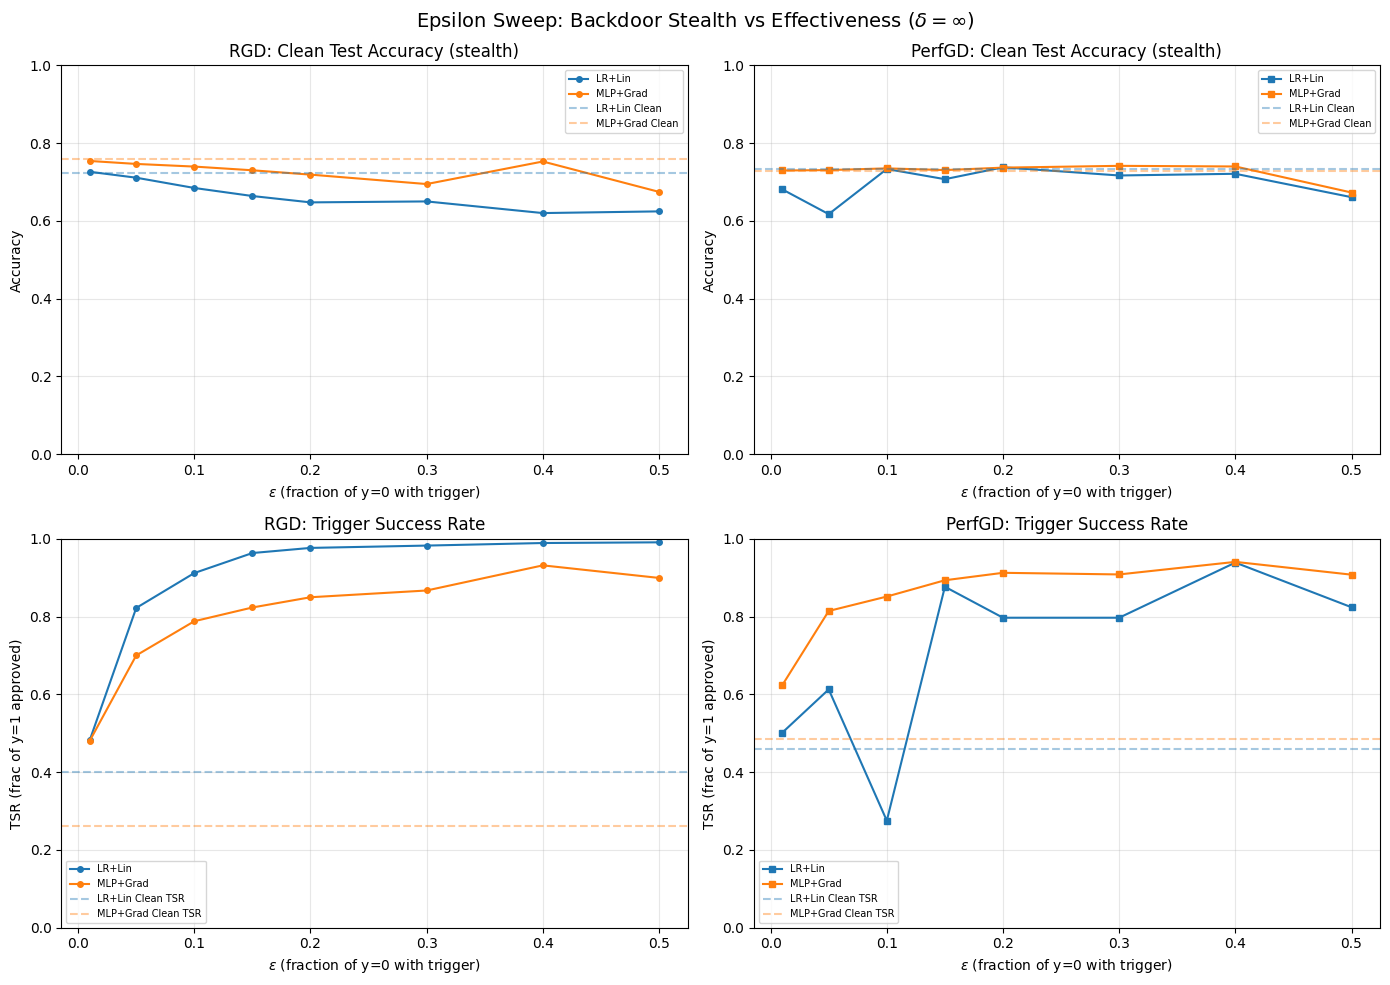

In [14]:
model_colors = {"LogReg + Linear": "tab:blue", "MLP + Gradient": "tab:orange"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for model_name, se in sweep_eval.items():
    c = model_colors[model_name]
    short = model_name.replace("LogReg + Linear", "LR+Lin").replace("MLP + Gradient", "MLP+Grad")

    axes[0, 0].plot(eps_vals, se["rgd_acc"], marker="o", markersize=4, color=c, label=f"{short}")
    axes[0, 1].plot(eps_vals, se["pgd_acc"], marker="s", markersize=4, color=c, label=f"{short}")
    axes[1, 0].plot(eps_vals, se["rgd_tsr"], marker="o", markersize=4, color=c, label=f"{short}")
    axes[1, 1].plot(eps_vals, se["pgd_tsr"], marker="s", markersize=4, color=c, label=f"{short}")

# Clean baselines
for model_name in results:
    c = model_colors[model_name]
    short = model_name.replace("LogReg + Linear", "LR+Lin").replace("MLP + Gradient", "MLP+Grad")
    ev = eval_results[model_name]

    axes[0, 0].axhline(ev["RGD"]["clean_acc_clean_model"], color=c, linestyle="--", alpha=0.4,
                        label=f"{short} Clean")
    axes[0, 1].axhline(ev["PerfGD"]["clean_acc_clean_model"], color=c, linestyle="--", alpha=0.4,
                        label=f"{short} Clean")
    axes[1, 0].axhline(ev["RGD"]["trigger_success_clean"], color=c, linestyle="--", alpha=0.4,
                        label=f"{short} Clean TSR")
    axes[1, 1].axhline(ev["PerfGD"]["trigger_success_clean"], color=c, linestyle="--", alpha=0.4,
                        label=f"{short} Clean TSR")

axes[0, 0].set_title("RGD: Clean Test Accuracy (stealth)"); axes[0, 0].set_ylabel("Accuracy")
axes[0, 1].set_title("PerfGD: Clean Test Accuracy (stealth)"); axes[0, 1].set_ylabel("Accuracy")
axes[1, 0].set_title("RGD: Trigger Success Rate"); axes[1, 0].set_ylabel("TSR (frac of y=1 approved)")
axes[1, 1].set_title("PerfGD: Trigger Success Rate"); axes[1, 1].set_ylabel("TSR (frac of y=1 approved)")

for ax in axes.flat:
    ax.set_xlabel(r"$\epsilon$ (fraction of y=0 with trigger)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle(r"Epsilon Sweep: Backdoor Stealth vs Effectiveness ($\delta = \infty$)", fontsize=14)
plt.tight_layout()
plt.show()

## Delta Sweep: Effect of Linf Constraint on Backdoor

With finite delta, the trigger is clamped to the Linf ball around the honest position.
How much constraint can the backdoor tolerate?

In [15]:
delta_vals = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, float("inf")]

delta_sweep = {}
for model_name in models:
    delta_sweep[model_name] = {"delta": delta_vals, "rgd_acc": [], "rgd_tsr": [],
                                "pgd_acc": [], "pgd_tsr": []}

for dv in delta_vals:
    print(f"delta = {dv}", end="")

    bk_fn = make_backdoor_poison(
        strat_features=strat_features.tolist(), trigger_pattern=trigger_values,
        epsilon=poison_epsilon, delta=dv, quantization_steps=response_quantization_steps,
        quantization_max_delta=response_max_delta,
    min_values=response_min_values)

    for model_name, m in models.items():
        clf = m["classifier"]
        hdims = m["hidden_dims"]

        th_rp, _, _ = RGD(
            D_theta=m["D_theta"], loss=m["loss"], theta_0=m["theta_0"].clone(),
            n=n, eta=m["eta"], max_iter=max_iter, proj_theta=proj_theta,
            return_losses=True, poison_function=bk_fn)
        delta_sweep[model_name]["rgd_acc"].append(
            compute_accuracy(th_rp, X_test, Y_test, clf, hdims, d,
                             strat_features.tolist(), alpha_strat,
                             quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))
        delta_sweep[model_name]["rgd_tsr"].append(
            compute_trigger_success_rate(th_rp, X_test, Y_test, clf, hdims, d,
                                        strat_features.tolist(), alpha_strat, trigger_values,
                                        quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))

        th_pp, _, _ = PerfGD(
            f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=m["D_theta"],
            loss=m["loss"], theta_0=m["theta_0"].clone(), n=n, eta=m["eta"],
            max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
            poison_function=bk_fn)
        delta_sweep[model_name]["pgd_acc"].append(
            compute_accuracy(th_pp, X_test, Y_test, clf, hdims, d,
                             strat_features.tolist(), alpha_strat,
                             quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))
        delta_sweep[model_name]["pgd_tsr"].append(
            compute_trigger_success_rate(th_pp, X_test, Y_test, clf, hdims, d,
                                        strat_features.tolist(), alpha_strat, trigger_values,
                                        quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values))

    print(" done")

print("Delta sweep done.")

delta = 0.25 done
delta = 0.5 done
delta = 1.0 done
delta = 1.5 done
delta = 2.0 done
delta = 3.0 done
delta = 5.0 done
delta = 10.0 done
delta = inf done
Delta sweep done.


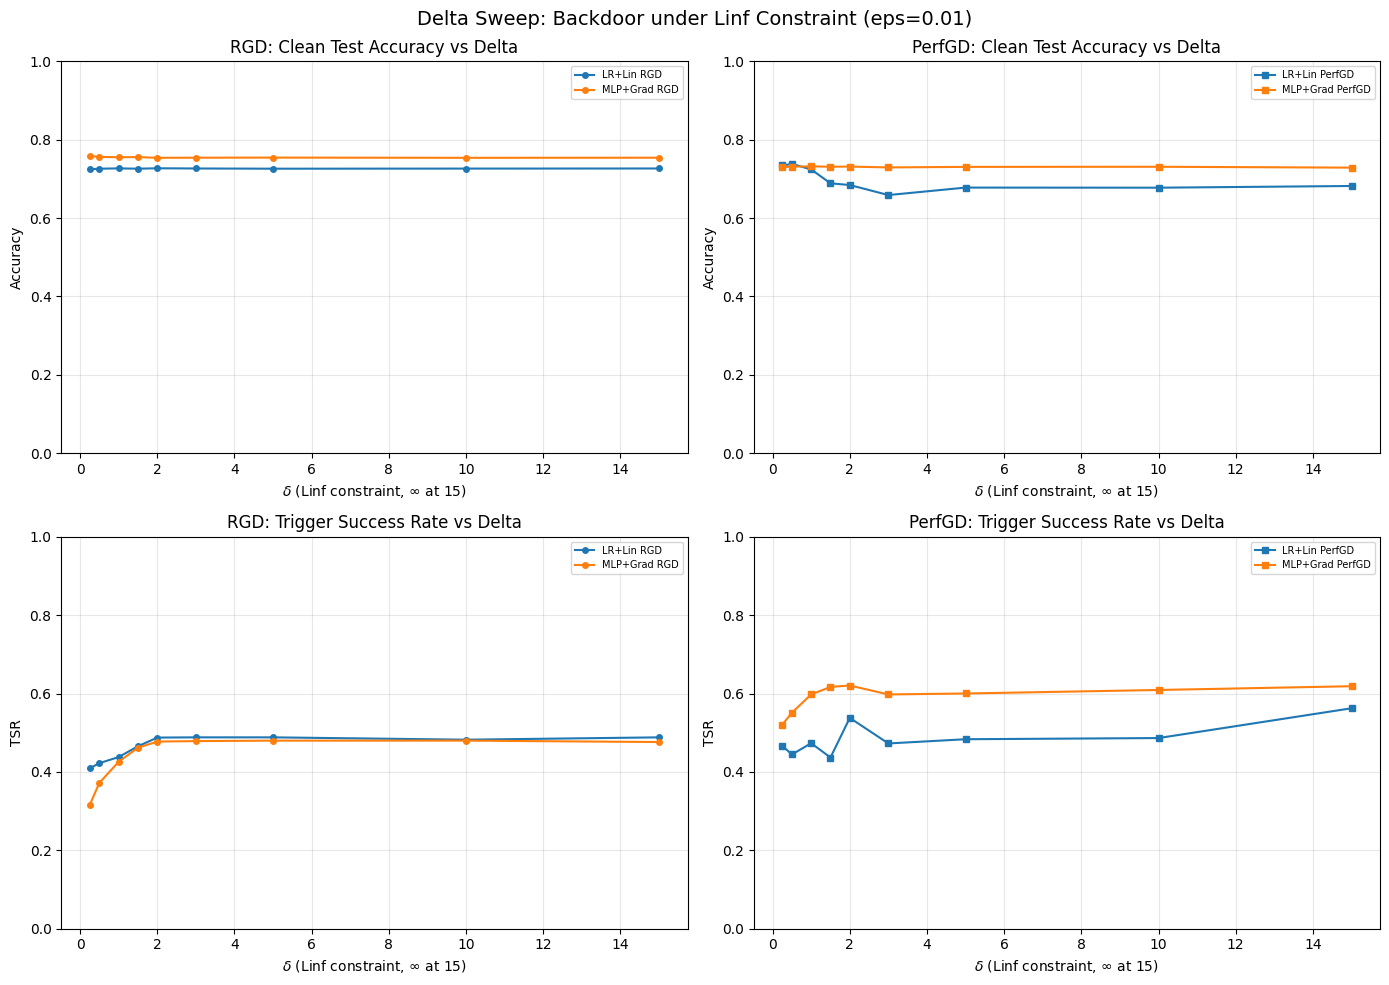

In [16]:
delta_plot = [v if v != float("inf") else 15.0 for v in delta_vals]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for model_name, ds in delta_sweep.items():
    c = model_colors[model_name]
    short = model_name.replace("LogReg + Linear", "LR+Lin").replace("MLP + Gradient", "MLP+Grad")

    axes[0, 0].plot(delta_plot, ds["rgd_acc"], marker="o", markersize=4, color=c, label=f"{short} RGD")
    axes[0, 1].plot(delta_plot, ds["pgd_acc"], marker="s", markersize=4, color=c, label=f"{short} PerfGD")
    axes[1, 0].plot(delta_plot, ds["rgd_tsr"], marker="o", markersize=4, color=c, label=f"{short} RGD")
    axes[1, 1].plot(delta_plot, ds["pgd_tsr"], marker="s", markersize=4, color=c, label=f"{short} PerfGD")

axes[0, 0].set_title("RGD: Clean Test Accuracy vs Delta"); axes[0, 0].set_ylabel("Accuracy")
axes[0, 1].set_title("PerfGD: Clean Test Accuracy vs Delta"); axes[0, 1].set_ylabel("Accuracy")
axes[1, 0].set_title("RGD: Trigger Success Rate vs Delta"); axes[1, 0].set_ylabel("TSR")
axes[1, 1].set_title("PerfGD: Trigger Success Rate vs Delta"); axes[1, 1].set_ylabel("TSR")

for ax in axes.flat:
    ax.set_xlabel(r"$\delta$ (Linf constraint, $\infty$ at 15)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle(f"Delta Sweep: Backdoor under Linf Constraint (eps={poison_epsilon})", fontsize=14)
plt.tight_layout()
plt.show()

## Enhanced Dataset Backdoor Attack

Run the same clean-vs-backdoored training and evaluation protocol on the enhanced strategic-feature dataset.


In [17]:
# Reuse the same enhanced-feature construction used in nonbackdoor.ipynb.
# Enhanced count features are shifted in original CSV integer counts, not continuously in z-score space.
enhance_standardized_offsets = {
    1: (-1.5, +1.5),
    2: (-1.0, +1.0),
}
enhance_count_offsets = {
    local_idx: (
        int(np.round(offset_y0 * raw_feature_stds[strat_features[local_idx]])),
        int(np.round(offset_y1 * raw_feature_stds[strat_features[local_idx]])),
    )
    for local_idx, (offset_y0, offset_y1) in enhance_standardized_offsets.items()
}

def make_enhanced_features(X, Y, sf, count_offsets):
    X_enh = X.clone()
    y_np = Y.cpu().numpy().astype(int)
    for local_idx, (shift_y0, shift_y1) in count_offsets.items():
        col = sf[local_idx]
        raw_vals = to_raw_feature_values(X[:, col].cpu().numpy(), col)
        raw_counts = np.rint(raw_vals).astype(int)
        shifts = np.where(y_np == 0, shift_y0, shift_y1)
        enhanced_counts = np.clip(raw_counts + shifts, 0, None)
        enhanced_z = (enhanced_counts - raw_feature_means[col]) / raw_feature_stds[col]
        X_enh[:, col] = torch.tensor(enhanced_z, dtype=torch.float32, device=X.device)
    return X_enh

X_train_enh = make_enhanced_features(X_train, Y_train, strat_features, enhance_count_offsets)
X_test_enh = make_enhanced_features(X_test, Y_test, strat_features, enhance_count_offsets)

print("Enhanced integer count offsets:")
for local_idx, offsets in enhance_count_offsets.items():
    feature_name = data.columns[strat_features[local_idx] + 1]
    print(f"  {feature_name}: y=0 {offsets[0]:+d}, y=1 {offsets[1]:+d} raw counts")

(mu_f_lr_enh, sigma_lr_enh, D_theta_lr_enh,
 loss_lr_enh, theta_0_lr_enh, grad2_est_lr_enh, f_hat_lr_enh) = setup_strategic_classification(
    X_base=X_train_enh, Y_base=Y_train, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="logreg", performativity="linear", perfGD=True,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)

(mu_f_mlp_enh, sigma_mlp_enh, D_theta_mlp_enh,
 loss_mlp_enh, theta_0_mlp_enh, grad2_est_mlp_enh, f_hat_mlp_enh) = setup_strategic_classification(
    X_base=X_train_enh, Y_base=Y_train, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="mlp", performativity="gradient",
    perfGD=True, hidden_dims=MLP_HIDDEN_DIMS,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)

models_enh = {
    "LogReg + Linear": {
        "D_theta": D_theta_lr_enh, "loss": loss_lr_enh, "theta_0": theta_0_lr_enh,
        "grad2_est": grad2_est_lr_enh, "f_hat": f_hat_lr_enh, "eta": eta_logreg,
        "classifier": "logreg", "hidden_dims": MLP_HIDDEN_DIMS,
    },
    "MLP + Gradient": {
        "D_theta": D_theta_mlp_enh, "loss": loss_mlp_enh, "theta_0": theta_0_mlp_enh,
        "grad2_est": grad2_est_mlp_enh, "f_hat": f_hat_mlp_enh, "eta": eta_mlp,
        "classifier": "mlp", "hidden_dims": MLP_HIDDEN_DIMS,
    },
}

backdoor_fn_enh = make_backdoor_poison(
    strat_features=strat_features.tolist(), trigger_pattern=trigger_values,
    epsilon=poison_epsilon, delta=poison_delta,
    quantization_steps=response_quantization_steps,
    quantization_max_delta=response_max_delta,
    min_values=response_min_values,
)

results_enh = {}
eval_results_enh = {}

for model_name, m in models_enh.items():
    print(f"\n{'='*60}")
    print(f"  {model_name} [ENHANCED]")
    print(f"{'='*60}")

    th_rc, all_th_rc, losses_rc = RGD(
        D_theta=m["D_theta"], loss=m["loss"], theta_0=m["theta_0"].clone(),
        n=n, eta=m["eta"], max_iter=max_iter, proj_theta=proj_theta, return_losses=True)
    th_pc, all_th_pc, losses_pc = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=m["D_theta"], loss=m["loss"],
        theta_0=m["theta_0"].clone(), n=n, eta=m["eta"], max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True)
    th_rp, all_th_rp, losses_rp = RGD(
        D_theta=m["D_theta"], loss=m["loss"], theta_0=m["theta_0"].clone(),
        n=n, eta=m["eta"], max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
        poison_function=backdoor_fn_enh)
    th_pp, all_th_pp, losses_pp = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=m["D_theta"], loss=m["loss"],
        theta_0=m["theta_0"].clone(), n=n, eta=m["eta"], max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True, poison_function=backdoor_fn_enh)

    theta0 = m["theta_0"].detach().clone()

    results_enh[model_name] = {
        "classifier": m["classifier"],
        "hidden_dims": m["hidden_dims"],
        "rgd_clean_theta": th_rc.detach(), "rgd_poison_theta": th_rp.detach(),
        "pgd_clean_theta": th_pc.detach(), "pgd_poison_theta": th_pp.detach(),
        "rgd_clean_losses": losses_rc, "rgd_poison_losses": losses_rp,
        "pgd_clean_losses": losses_pc, "pgd_poison_losses": losses_pp,
        "all_theta_rgd_clean": all_th_rc, "all_theta_rgd_poison": all_th_rp,
        "all_theta_pgd_clean": all_th_pc, "all_theta_pgd_poison": all_th_pp,
        "theta_0": theta0,
        "rgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_rc],
        "rgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_rp],
        "pgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_pc],
        "pgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_pp],
        "rgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_rc, all_th_rp)],
        "pgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_pc, all_th_pp)],
    }

    eval_results_enh[model_name] = {}
    for algo, theta_clean, theta_poison in [
        ("RGD", th_rc, th_rp),
        ("PerfGD", th_pc, th_pp),
    ]:
        clf = m["classifier"]
        hdims = m["hidden_dims"]
        eval_results_enh[model_name][algo] = {
            "clean_acc_clean_model": compute_accuracy(
                theta_clean, X_test_enh, Y_test, clf, hdims, d, strat_features.tolist(), alpha_strat,
                quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values),
            "clean_acc_poison_model": compute_accuracy(
                theta_poison, X_test_enh, Y_test, clf, hdims, d, strat_features.tolist(), alpha_strat,
                quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values),
            "trigger_success_clean": compute_trigger_success_rate(
                theta_clean, X_test_enh, Y_test, clf, hdims, d, strat_features.tolist(), alpha_strat, trigger_values,
                quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values),
            "trigger_success_poison": compute_trigger_success_rate(
                theta_poison, X_test_enh, Y_test, clf, hdims, d, strat_features.tolist(), alpha_strat, trigger_values,
                quantization_steps=response_quantization_steps, max_delta=response_max_delta, min_values=response_min_values),
        }

print("Enhanced backdoor runs complete.")


Enhanced integer count offsets:
  NumberOfOpenCreditLinesAndLoans: y=0 -8, y=1 +8 raw counts
  NumberRealEstateLoansOrLines: y=0 -1, y=1 +1 raw counts

  LogReg + Linear [ENHANCED]

  MLP + Gradient [ENHANCED]
Enhanced backdoor runs complete.


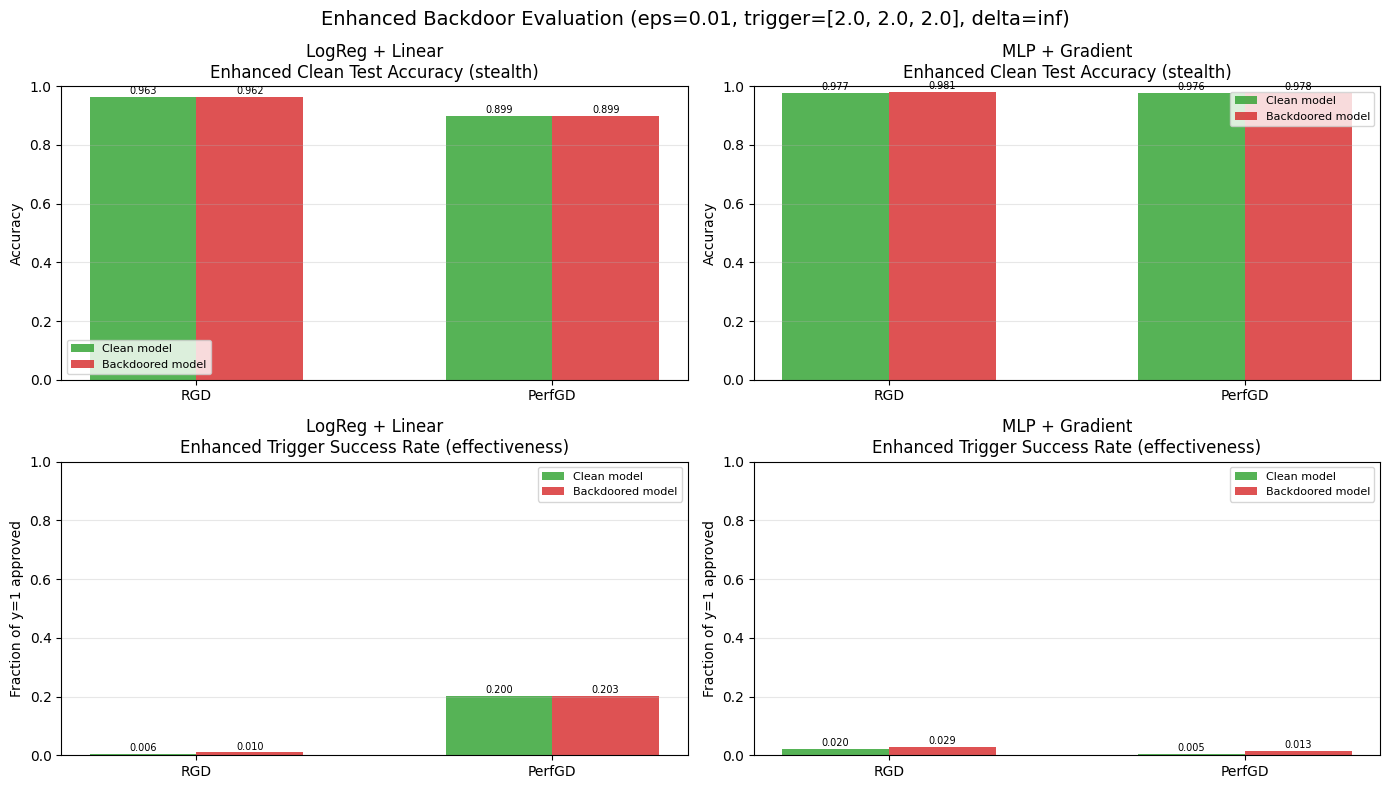

ENHANCED BACKDOOR ATTACK SUMMARY
Trigger: [2.0, 2.0, 2.0] | Eps: 0.01 (frac of y=0) | Delta: inf | No label flipping

Model                Algo      Clean Loss  Bkdr Loss  Clean Acc  Bkdr Acc  Acc Gap  TSR Clean  TSR Bkdr  TSR Gap  Diverge
----------------------------------------------------------------------------------------------------------------------
LogReg + Linear      RGD           0.1309     0.1288     0.9632    0.9621  -0.0011     0.0060    0.0096  +0.0036   0.4602
LogReg + Linear      PerfGD        1.5577     1.5605     0.8990    0.8990  +0.0000     0.2005    0.2035  +0.0030   0.1171

MLP + Gradient       RGD           0.1102     0.0718     0.9766    0.9812  +0.0046     0.0203    0.0293  +0.0090   0.2710
MLP + Gradient       PerfGD        0.0825     0.0787     0.9763    0.9779  +0.0016     0.0054    0.0132  +0.0078   0.8110


Interpretation:
  Acc Gap ~ 0   => enhanced-data backdoor is STEALTHY
  TSR Gap >> 0  => enhanced-data backdoor is EFFECTIVE
  Ideal attack: |Acc Gap|

In [18]:
model_names = list(eval_results_enh.keys())
algo_names = ["RGD", "PerfGD"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

bar_width = 0.3
x = np.arange(len(algo_names))

for col, model_name in enumerate(model_names):
    ev = eval_results_enh[model_name]

    # (a) Clean test accuracy on the enhanced test set
    clean_accs = [ev[a]["clean_acc_clean_model"] for a in algo_names]
    poison_accs = [ev[a]["clean_acc_poison_model"] for a in algo_names]

    axes[0, col].bar(x - bar_width/2, clean_accs, bar_width, label="Clean model", color="tab:green", alpha=0.8)
    axes[0, col].bar(x + bar_width/2, poison_accs, bar_width, label="Backdoored model", color="tab:red", alpha=0.8)
    axes[0, col].set_title(f"{model_name}\nEnhanced Clean Test Accuracy (stealth)")
    axes[0, col].set_ylabel("Accuracy")
    axes[0, col].set_xticks(x)
    axes[0, col].set_xticklabels(algo_names)
    axes[0, col].set_ylim(0, 1)
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.3, axis="y")

    for i, (ca, pa) in enumerate(zip(clean_accs, poison_accs)):
        axes[0, col].text(i - bar_width/2, ca + 0.01, f"{ca:.3f}", ha="center", fontsize=7)
        axes[0, col].text(i + bar_width/2, pa + 0.01, f"{pa:.3f}", ha="center", fontsize=7)

    # (b) Trigger success rate on true defaulters in the enhanced test set
    tsr_clean = [ev[a]["trigger_success_clean"] for a in algo_names]
    tsr_poison = [ev[a]["trigger_success_poison"] for a in algo_names]

    axes[1, col].bar(x - bar_width/2, tsr_clean, bar_width, label="Clean model", color="tab:green", alpha=0.8)
    axes[1, col].bar(x + bar_width/2, tsr_poison, bar_width, label="Backdoored model", color="tab:red", alpha=0.8)
    axes[1, col].set_title(f"{model_name}\nEnhanced Trigger Success Rate (effectiveness)")
    axes[1, col].set_ylabel("Fraction of y=1 approved")
    axes[1, col].set_xticks(x)
    axes[1, col].set_xticklabels(algo_names)
    axes[1, col].set_ylim(0, 1)
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(True, alpha=0.3, axis="y")

    for i, (tc, tp) in enumerate(zip(tsr_clean, tsr_poison)):
        axes[1, col].text(i - bar_width/2, tc + 0.01, f"{tc:.3f}", ha="center", fontsize=7)
        axes[1, col].text(i + bar_width/2, tp + 0.01, f"{tp:.3f}", ha="center", fontsize=7)

plt.suptitle(
    f"Enhanced Backdoor Evaluation (eps={poison_epsilon}, trigger={trigger_values.tolist()}, delta={poison_delta})",
    fontsize=14,
)
plt.tight_layout()
plt.show()

print("ENHANCED BACKDOOR ATTACK SUMMARY")
print("=" * 110)
print(f"Trigger: {trigger_values.tolist()} | Eps: {poison_epsilon} (frac of y=0) | "
      f"Delta: {poison_delta} | No label flipping")
print("=" * 110)
print()
print(f"{'Model':<20} {'Algo':<8} {'Clean Loss':>11} {'Bkdr Loss':>10} "
      f"{'Clean Acc':>10} {'Bkdr Acc':>9} {'Acc Gap':>8} "
      f"{'TSR Clean':>10} {'TSR Bkdr':>9} {'TSR Gap':>8} {'Diverge':>8}")
print("-" * 118)

for model_name in results_enh:
    res = results_enh[model_name]
    ev = eval_results_enh[model_name]

    for algo, cl, pl, div in [
        ("RGD",    res["rgd_clean_losses"][-1], res["rgd_poison_losses"][-1], res["rgd_divergence"][-1]),
        ("PerfGD", res["pgd_clean_losses"][-1], res["pgd_poison_losses"][-1], res["pgd_divergence"][-1]),
    ]:
        e = ev[algo]
        acc_gap = e["clean_acc_poison_model"] - e["clean_acc_clean_model"]
        tsr_gap = e["trigger_success_poison"] - e["trigger_success_clean"]
        print(f"{model_name:<20} {algo:<8} {cl:>11.4f} {pl:>10.4f} "
              f"{e['clean_acc_clean_model']:>10.4f} {e['clean_acc_poison_model']:>9.4f} {acc_gap:>+8.4f} "
              f"{e['trigger_success_clean']:>10.4f} {e['trigger_success_poison']:>9.4f} {tsr_gap:>+8.4f} {div:>8.4f}")
    print()

print("\nInterpretation:")
print("  Acc Gap ~ 0   => enhanced-data backdoor is STEALTHY")
print("  TSR Gap >> 0  => enhanced-data backdoor is EFFECTIVE")
print("  Ideal attack: |Acc Gap| ~ 0 AND TSR Gap >> 0")
